# Calibration assessment — Perpetration model

This notebook evaluates calibration for the perpetration model using the held-out prediction file.

It does **not** retrain, recalibrate, or change the selected threshold.  
It only checks whether the model's continuous output score (`y_prob_pos`) is aligned with the observed prevalence (`y_true`) in the held-out partition.

Main input file:

- `predictions_with_probs.csv`

Columns used:

- `y_true`: observed outcome, coded 0/1
- `y_prob_pos`: model score/probability for the positive class
- `y_pred`: binary prediction after the selected threshold, used only for sanity checks


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    brier_score_loss,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)


In [2]:
# Load predictions
pred_path = "predictions_with_probs.csv"

df_pred = pd.read_csv(pred_path)

print("Shape:", df_pred.shape)
print("Columns:", list(df_pred.columns))
display(df_pred.head())


Shape: (942, 4)
Columns: ['idx_original', 'y_true', 'y_pred', 'y_prob_pos']


,idx_original,y_true,y_pred,y_prob_pos
0,1,1,1,0.547246
1,2,0,1,0.532639
2,5,0,1,0.597803
3,11,0,1,0.514838
4,13,0,1,0.536135


In [3]:
# Define calibration inputs
y_true = df_pred["y_true"].to_numpy().ravel()
y_score = df_pred["y_prob_pos"].to_numpy().ravel()

# Optional: binary predictions already produced by the selected threshold
y_pred = df_pred["y_pred"].to_numpy().ravel() if "y_pred" in df_pred.columns else None

print("n y_true:", len(y_true))
print("n y_score:", len(y_score))
print("Values in y_true:", np.unique(y_true))
print("Score min:", y_score.min())
print("Score max:", y_score.max())
print("Mean predicted score:", y_score.mean())
print("Observed prevalence:", y_true.mean())
print("Number of unique scores:", len(np.unique(y_score)))

if len(y_true) != len(y_score):
    raise ValueError("y_true and y_score have different lengths.")

if not set(np.unique(y_true)).issubset({0, 1}):
    raise ValueError("y_true should contain only 0 and 1.")

if y_score.min() < 0 or y_score.max() > 1:
    print("WARNING: y_score contains values outside 0–1.")

if len(np.unique(y_score)) <= 2:
    print("WARNING: y_score looks binary. Check that you are not using y_pred instead of probabilities.")


n y_true: 942
n y_score: 942
Values in y_true: [0 1]
Score min: 0.4399148
Score max: 0.68442285
Mean predicted score: 0.5300716717515924
Observed prevalence: 0.2346072186836518
Number of unique scores: 942


In [4]:
# Sanity check: classification report from stored y_pred
# This is not used for calibration; it only verifies that the prediction file matches the final report.
if y_pred is not None:
    print(classification_report(y_true, y_pred, digits=6))
    print("Confusion matrix:")
    print(confusion_matrix(y_true, y_pred))

    print("\nScore ranges by predicted class:")
    display(
        df_pred.groupby("y_pred")["y_prob_pos"]
        .agg(["min", "max", "count", "mean"])
        .reset_index()
    )


              precision    recall  f1-score   support

           0   0.917603  0.339806  0.495951       721
           1   0.294815  0.900452  0.444196       221

    accuracy                       0.471338       942
   macro avg   0.606209  0.620129  0.470074       942
weighted avg   0.771492  0.471338  0.483809       942

Confusion matrix:
[[245 476]
 [ 22 199]]

Score ranges by predicted class:


,y_pred,min,max,count,mean
0,0,0.439915,0.499955,267,0.480701
1,1,0.500006,0.684423,675,0.549601


In [5]:
def calibration_report(y_true, y_score, model_name, n_bins=10):
    y_true = np.asarray(y_true).ravel()
    y_score = np.asarray(y_score).ravel()

    brier = brier_score_loss(y_true, y_score)
    prevalence = y_true.mean()
    brier_baseline = np.mean((y_true - prevalence) ** 2)

    prob_true, prob_pred = calibration_curve(
        y_true,
        y_score,
        n_bins=n_bins,
        strategy="quantile"
    )

    print(f"=== {model_name} ===")
    print(f"n: {len(y_true)}")
    print(f"Observed prevalence: {prevalence:.4f}")
    print(f"Mean predicted score: {y_score.mean():.4f}")
    print(f"Brier score: {brier:.4f}")
    print(f"Brier baseline prevalence-only: {brier_baseline:.4f}")
    print(f"ROC AUC, ranking only: {roc_auc_score(y_true, y_score):.4f}")
    print(f"Average precision, ranking only: {average_precision_score(y_true, y_score):.4f}")

    df = pd.DataFrame({
        "y_true": y_true,
        "y_score": y_score
    })

    df["score_bin"] = pd.qcut(
        df["y_score"],
        q=n_bins,
        duplicates="drop"
    )

    table = (
        df.groupby("score_bin", observed=True)
          .agg(
              n=("y_true", "size"),
              positives=("y_true", "sum"),
              mean_predicted_score=("y_score", "mean"),
              observed_prevalence=("y_true", "mean"),
              min_score=("y_score", "min"),
              max_score=("y_score", "max")
          )
          .reset_index()
    )

    table["score_bin"] = table["score_bin"].astype(str)

    curve_points = pd.DataFrame({
        "mean_predicted_score": prob_pred,
        "observed_prevalence": prob_true
    })

    plt.figure(figsize=(6, 6))
    plt.plot(prob_pred, prob_true, marker="o", label=model_name)
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
    plt.xlabel("Mean predicted score")
    plt.ylabel("Observed prevalence")
    plt.title(f"Calibration curve — {model_name}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    summary = pd.DataFrame([{
        "model": model_name,
        "n": len(y_true),
        "prevalence_observed": prevalence,
        "mean_predicted_score": y_score.mean(),
        "score_min": y_score.min(),
        "score_max": y_score.max(),
        "n_unique_scores": len(np.unique(y_score)),
        "brier_score": brier,
        "brier_baseline_prevalence_only": brier_baseline,
        "roc_auc_score_ranking_only": roc_auc_score(y_true, y_score),
        "average_precision_score_ranking_only": average_precision_score(y_true, y_score)
    }])

    return summary, table, curve_points


=== Perpetration ===
n: 942
Observed prevalence: 0.2346
Mean predicted score: 0.5301
Brier score: 0.2578
Brier baseline prevalence-only: 0.1796
ROC AUC, ranking only: 0.7000
Average precision, ranking only: 0.3896


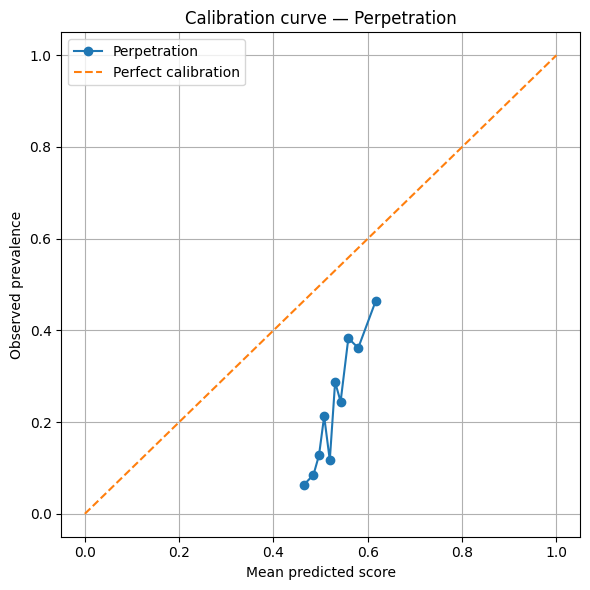

,model,n,prevalence_observed,mean_predicted_score,score_min,score_max,n_unique_scores,brier_score,brier_baseline_prevalence_only,roc_auc_score_ranking_only,average_precision_score_ranking_only
0,Perpetration,942,0.234607,0.530072,0.439915,0.684423,942,0.257807,0.179567,0.699971,0.389569


,score_bin,n,positives,mean_predicted_score,observed_prevalence,min_score,max_score
0,"(0.439, 0.479]",95,6,0.464363,0.063158,0.439915,0.478692
1,"(0.479, 0.491]",94,8,0.484789,0.085106,0.478888,0.490724
2,"(0.491, 0.502]",94,12,0.496544,0.127660,0.490754,0.501599
3,"(0.502, 0.513]",94,20,0.507452,0.212766,0.501610,0.513383
4,"(0.513, 0.525]",94,11,0.519399,0.117021,0.513436,0.524624
5,"(0.525, 0.536]",94,27,0.530689,0.287234,0.524736,0.535839
6,"(0.536, 0.548]",94,23,0.542361,0.244681,0.535952,0.547974
7,"(0.548, 0.57]",94,36,0.558751,0.382979,0.548554,0.570016
8,"(0.57, 0.593]",94,34,0.579695,0.361702,0.570058,0.592806
9,"(0.593, 0.684]",95,44,0.616456,0.463158,0.593360,0.684423


,mean_predicted_score,observed_prevalence
0,0.464363,0.063158
1,0.484789,0.085106
2,0.496544,0.127660
3,0.507452,0.212766
4,0.519399,0.117021
5,0.530689,0.287234
6,0.542361,0.244681
7,0.558751,0.382979
8,0.579695,0.361702
9,0.616456,0.463158


In [6]:
summary_perp, table_perp, curve_perp = calibration_report(
    y_true=y_true,
    y_score=y_score,
    model_name="Perpetration",
    n_bins=10
)

display(summary_perp)
display(table_perp)
display(curve_perp)


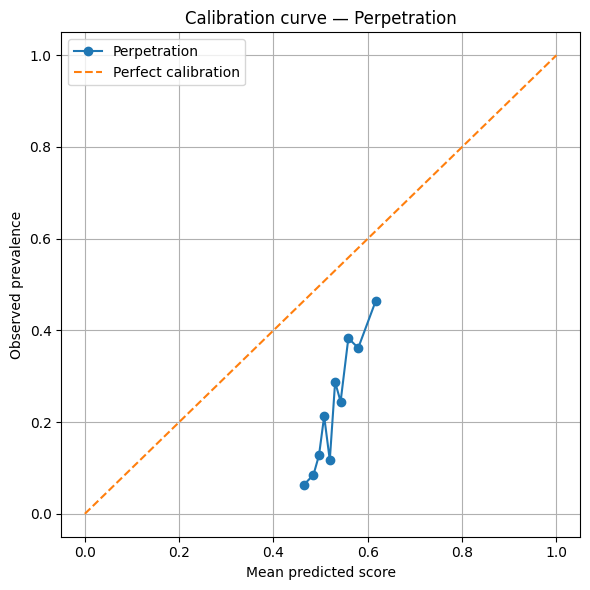

Saved:
- perpetration_calibration_summary.csv
- perpetration_calibration_table_quantile_bins.csv
- perpetration_calibration_curve_points.csv
- perpetration_calibration_curve.png


In [7]:
# Save outputs
summary_perp.to_csv("perpetration_calibration_summary.csv", index=False)
table_perp.to_csv("perpetration_calibration_table_quantile_bins.csv", index=False)
curve_perp.to_csv("perpetration_calibration_curve_points.csv", index=False)

# Save figure as PNG
plt.figure(figsize=(6, 6))
plt.plot(curve_perp["mean_predicted_score"], curve_perp["observed_prevalence"], marker="o", label="Perpetration")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.xlabel("Mean predicted score")
plt.ylabel("Observed prevalence")
plt.title("Calibration curve — Perpetration")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("perpetration_calibration_curve.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved:")
print("- perpetration_calibration_summary.csv")
print("- perpetration_calibration_table_quantile_bins.csv")
print("- perpetration_calibration_curve_points.csv")
print("- perpetration_calibration_curve.png")


## Interpretation guide

For this model, the key issue is whether the mean predicted scores are close to the observed prevalence within each score bin.

If the points lie close to the diagonal, the scores can be interpreted more like probabilities.  
If the points lie systematically below the diagonal, the model is overestimating the positive-class probability.  
If the points lie systematically above the diagonal, the model is underestimating the positive-class probability.

In this run, the predicted scores are much higher than the observed prevalence across the score range, so the outputs should be interpreted as screening/prioritization scores rather than calibrated individual probability estimates.
